In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import time

# bibliotecas do scikit-learn
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)


In [2]:
# definindo caminhos
pasta_treino_teste = '../dados/dados_processados/treino_teste/'
pasta_modelos = '../modelos/'

print("Carregando conjuntos de treino e teste\n")

# carregando atributos das 3 versões
X_train_orig = pd.read_csv(os.path.join(pasta_treino_teste, 'X_train_original.csv'))
X_test_orig = pd.read_csv(os.path.join(pasta_treino_teste, 'X_test_original.csv'))

X_train_pca = pd.read_csv(os.path.join(pasta_treino_teste, 'X_train_pca.csv'))
X_test_pca = pd.read_csv(os.path.join(pasta_treino_teste, 'X_test_pca.csv'))

X_train_lda = pd.read_csv(os.path.join(pasta_treino_teste, 'X_train_lda.csv'))
X_test_lda = pd.read_csv(os.path.join(pasta_treino_teste, 'X_test_lda.csv'))

# carregando rótulos
y_train = pd.read_csv(os.path.join(pasta_treino_teste, 'y_train.csv')).iloc[:, 0]
y_test = pd.read_csv(os.path.join(pasta_treino_teste, 'y_test.csv')).iloc[:, 0]

# carregando codificador
codificador = joblib.load(os.path.join(pasta_modelos, 'codificador_rotulos_amostrado.pkl'))

print("Dados carregados\n")
print(f" Treino: {len(y_train):,} registros | Teste: {len(y_test):,} registros")
print(f" Classes: {list(codificador.classes_)}")

print(f"\nFormatos:")
print(f"{'Versão':<12} {'X_train':<15} {'X_test':<15}")
print("=" * 45)
print(f"{'Original':<12} {str(X_train_orig.shape):<15} {str(X_test_orig.shape):<15}")
print(f"{'PCA':<12} {str(X_train_pca.shape):<15} {str(X_test_pca.shape):<15}")
print(f"{'LDA':<12} {str(X_train_lda.shape):<15} {str(X_test_lda.shape):<15}")


Carregando conjuntos de treino e teste

Dados carregados

 Treino: 7,000 registros | Teste: 3,000 registros
 Classes: ['BENIGN', 'DDoS', 'DoS Hulk', 'PortScan']

Formatos:
Versão       X_train         X_test         
Original     (7000, 78)      (3000, 78)     
PCA          (7000, 15)      (3000, 15)     
LDA          (7000, 3)       (3000, 3)      


C:\Users\William\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
# o isolation forest é um modelo do tipo não-supervisionado e detecta anomalias
# então precisamos converter os rótulos para o formato binário: 0 = normal / benign, 1 = ataque / anomalia
idx_benign = list(codificador.classes_).index('BENIGN')
print(f"Índice da classe BENIGN: {idx_benign}\n")

# criando rótulos binários
y_train_bin = (y_train != idx_benign).astype(int)
y_test_bin = (y_test != idx_benign).astype(int)

# verificando distribuição
print("Distribuição binária no treino:")
print(f"   Normal (0): {np.sum(y_train_bin==0):,} ({np.mean(y_train_bin==0)*100:.2f}%)")
print(f"   Ataque (1): {np.sum(y_train_bin==1):,} ({np.mean(y_train_bin==1)*100:.2f}%)")

print("\nDistribuição binária no teste:")
print(f"   Normal (0): {np.sum(y_test_bin==0):,} ({np.mean(y_test_bin==0)*100:.2f}%)")
print(f"   Ataque (1): {np.sum(y_test_bin==1):,} ({np.mean(y_test_bin==1)*100:.2f}%)")


Índice da classe BENIGN: 0

Distribuição binária no treino:
   Normal (0): 1,750 (25.00%)
   Ataque (1): 5,250 (75.00%)

Distribuição binária no teste:
   Normal (0): 750 (25.00%)
   Ataque (1): 2,250 (75.00%)


In [4]:
# configuração dos hiperparâmetros do isolation forest
# valores escolhidos com base em boas práticas para detecção de anomalias

config_if = {
    'n_estimators': 100,         # quantidade de árvores
    'max_samples': 'auto',       # amostras por árvore
    'contamination': 'auto',     # estima a proporção de anomalias automaticamente
    'max_features': 1.0,         # usa todas as features em cada árvore
    'bootstrap': False,          # sem reamostragem com reposição
    'random_state': 1,           # valor da seed usada em todo projeto
    'n_jobs': -1,                # usa todos os cores da CPU
    'verbose': 0                 # sem output durante treinamento
}

print(" Configuração do Isolation Forest:")
print("=" * 50)
for param, valor in config_if.items():
    print(f"   {param:<20} = {valor}")
print("=" * 50)


 Configuração do Isolation Forest:
   n_estimators         = 100
   max_samples          = auto
   contamination        = auto
   max_features         = 1.0
   bootstrap            = False
   random_state         = 1
   n_jobs               = -1
   verbose              = 0


In [5]:
# função reutilizável para treinar e avaliar um isolation forest
# ela vai ser chamada 3 vezes, uma para cada versão, original, lda e pca

def treinar_e_avaliar_if(X_train, X_test, y_train_bin, y_test_bin, nome_versao, config):
    """
    treina um isolation forest e retorna as métricas e o modelo

    parâmetros:
    X_train, X_test         : conjuntos de atributos
    y_train_bin, y_test_bin : rótulos binários (0 = normal, 1 = ataque)
    nome_versao             : str, nome da versão (Original, PCA, LDA)
    config                  : dict, hiperparâmetros do modelo

    Retorna:
    --------
    dict com modelo, predições, métricas e tempos
    """
    print(f"\n{'='*60}")
    print(f"Treinando Isolation Forest — Versão {nome_versao}")
    print(f"{'='*60}")
    print(f" Atributos: {X_train.shape[1]}")
    print(f" Treino:    {X_train.shape[0]:,} registros")
    print(f" Teste:     {X_test.shape[0]:,} registros")

    # criando o modelo
    modelo = IsolationForest(**config)

    # treinamento para medir o tempo de execução
    # isolation forest não usa os rótulos por ser não-supervisionado
    print(f"\n Treinando modelo")
    inicio_treino = time.time()
    modelo.fit(X_train)
    tempo_treino = time.time() - inicio_treino
    print(f" Treinamento concluído em {tempo_treino:.2f} segundos")

    # predição para medir o tempo de execução
    print(f" Realizando predições")
    inicio_pred = time.time()
    y_pred_raw = modelo.predict(X_test)   # retorna 1 normal ou -1 anomalia
    tempo_pred = time.time() - inicio_pred
    print(f" Predição concluída em {tempo_pred:.4f} segundos")

    # convertendo a saída: -1 anomalia -> 1 ataque | 1 normal -> 0
    y_pred = np.where(y_pred_raw == -1, 1, 0)

    # scores de anomalia, quanto maior, maior a chance de ser ataque)
    scores = -modelo.score_samples(X_test)

    # calculando as métricas
    acuracia = accuracy_score(y_test_bin, y_pred)
    precisao = precision_score(y_test_bin, y_pred, zero_division=0)
    recall = recall_score(y_test_bin, y_pred, zero_division=0)
    f1 = f1_score(y_test_bin, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test_bin, scores)

    print(f"\nMétricas:")
    print(f"   Acurácia:  {acuracia*100:.2f}%")
    print(f"   Precisão:  {precisao*100:.2f}%")
    print(f"   Recall:    {recall*100:.2f}%")
    print(f"   F1-Score:  {f1*100:.2f}%")
    print(f"   ROC-AUC:   {roc_auc*100:.2f}%")

    # retorna tudo em um dicionário
    return {
        'nome': nome_versao,
        'modelo': modelo,
        'y_pred': y_pred,
        'scores': scores,
        'tempo_treino': tempo_treino,
        'tempo_pred': tempo_pred,
        'acuracia': acuracia,
        'precisao': precisao,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }


In [6]:
# treinando o isolation forest nas 3 versões dos dados
print("Iniciando treinamento dos 3 modelos Isolation Forest\n")

resultados = {}

# versão 1 com dados originais
resultados['Original'] = treinar_e_avaliar_if(
    X_train_orig, X_test_orig, y_train_bin, y_test_bin,
    nome_versao='Original',
    config=config_if
)

# versão 2 com dados com PCA
resultados['PCA'] = treinar_e_avaliar_if(
    X_train_pca, X_test_pca, y_train_bin, y_test_bin,
    nome_versao='PCA',
    config=config_if
)

# versão 3 com dados com LDA
resultados['LDA'] = treinar_e_avaliar_if(
    X_train_lda, X_test_lda, y_train_bin, y_test_bin,
    nome_versao='LDA',
    config=config_if
)

print(f"\n{'='*60}")
print(f"Todos os modelos foram treinados")
print(f"{'='*60}")


Iniciando treinamento dos 3 modelos Isolation Forest


Treinando Isolation Forest — Versão Original
 Atributos: 78
 Treino:    7,000 registros
 Teste:     3,000 registros

 Treinando modelo
 Treinamento concluído em 0.29 segundos
 Realizando predições
 Predição concluída em 0.0422 segundos

Métricas:
   Acurácia:  23.67%
   Precisão:  39.69%
   Recall:    3.42%
   F1-Score:  6.30%
   ROC-AUC:   39.30%

Treinando Isolation Forest — Versão PCA
 Atributos: 15
 Treino:    7,000 registros
 Teste:     3,000 registros

 Treinando modelo
 Treinamento concluído em 0.17 segundos
 Realizando predições
 Predição concluída em 0.0253 segundos

Métricas:
   Acurácia:  25.87%
   Precisão:  55.16%
   Recall:    6.18%
   F1-Score:  11.11%
   ROC-AUC:   39.83%

Treinando Isolation Forest — Versão LDA
 Atributos: 3
 Treino:    7,000 registros
 Teste:     3,000 registros

 Treinando modelo
 Treinamento concluído em 0.16 segundos
 Realizando predições
 Predição concluída em 0.0259 segundos

Métricas:
   Acu

grafico salvo em: ../figuras/roc_isolation_forest.png


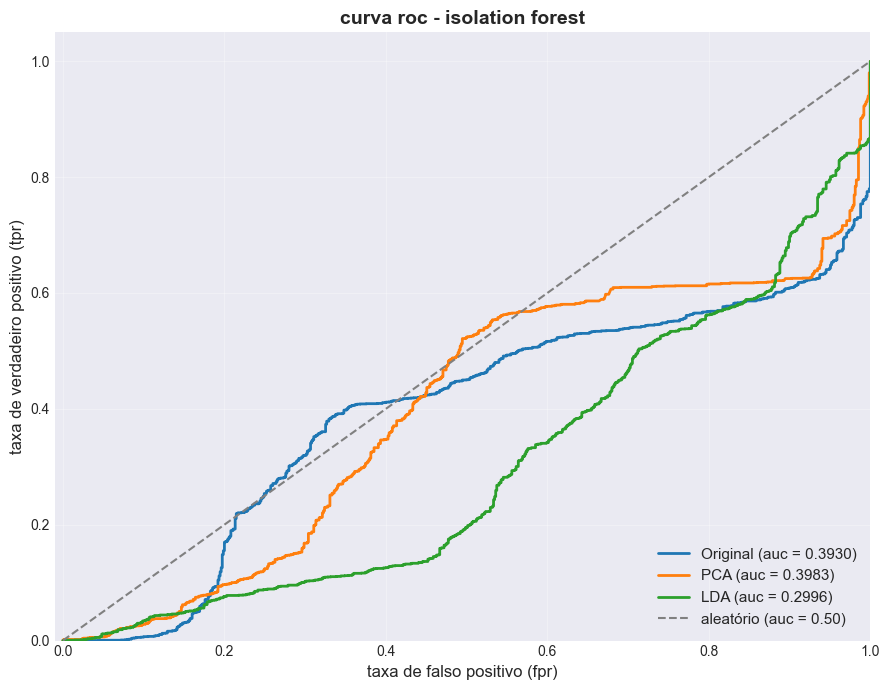

In [14]:
from sklearn.metrics import roc_curve, auc

# gerando a curva roc para cada versão dos dados
plt.figure(figsize=(9, 7))

cores = {'Original': '#1f77b4', 'PCA': '#ff7f0e', 'LDA': '#2ca02c'}

for nome_versao, res in resultados.items():
    # roc_curve retorna fpr, tpr e thresholds
    fpr, tpr, _ = roc_curve(y_test_bin, res['scores'])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(
        fpr, tpr,
        color=cores[nome_versao],
        lw=2,
        label=f"{nome_versao} (auc = {roc_auc:.4f})"
    )

# linha diagonal de referência (classificador aleatório)
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='aleatório (auc = 0.50)')

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('taxa de falso positivo (fpr)', fontsize=12)
plt.ylabel('taxa de verdadeiro positivo (tpr)', fontsize=12)
plt.title('curva roc - isolation forest', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# salvando o gráfico
pasta_figuras = '../figuras/'
os.makedirs(pasta_figuras, exist_ok=True)
caminho_fig = os.path.join(pasta_figuras, 'roc_isolation_forest.png')
plt.savefig(caminho_fig, dpi=150, bbox_inches='tight')
print(f"grafico salvo em: {caminho_fig}")

plt.show()


In [7]:
# criando tabela comparativa com todas as métricas
print("TABELA COMPARATIVA — Isolation Forest nas 3 versões\n")

# construindo dataframe com os resultados
df_comparacao = pd.DataFrame({
    'Versão': [r['nome'] for r in resultados.values()],
    'Atributos': [
        X_train_orig.shape[1],
        X_train_pca.shape[1],
        X_train_lda.shape[1]
    ],
    'Acurácia (%)': [r['acuracia']*100 for r in resultados.values()],
    'Precisão (%)': [r['precisao']*100 for r in resultados.values()],
    'Recall (%)': [r['recall']*100 for r in resultados.values()],
    'F1-Score (%)': [r['f1']*100 for r in resultados.values()],
    'ROC-AUC (%)': [r['roc_auc']*100 for r in resultados.values()],
    'Tempo Treino (s)': [r['tempo_treino'] for r in resultados.values()],
    'Tempo Pred. (s)': [r['tempo_pred'] for r in resultados.values()]
})

# formatando para exibição
df_comparacao_formatado = df_comparacao.copy()
for col in ['Acurácia (%)', 'Precisão (%)', 'Recall (%)', 'F1-Score (%)', 'ROC-AUC (%)']:
    df_comparacao_formatado[col] = df_comparacao_formatado[col].apply(lambda x: f"{x:.2f}")
df_comparacao_formatado['Tempo Treino (s)'] = df_comparacao_formatado['Tempo Treino (s)'].apply(lambda x: f"{x:.2f}")
df_comparacao_formatado['Tempo Pred. (s)'] = df_comparacao_formatado['Tempo Pred. (s)'].apply(lambda x: f"{x:.4f}")

print(df_comparacao_formatado.to_string(index=False))

# identificando o melhor modelo por F1-Score
melhor_versao = df_comparacao.loc[df_comparacao['F1-Score (%)'].idxmax(), 'Versão']
print(f"\nMelhor versão (por F1-Score): {melhor_versao}")


TABELA COMPARATIVA — Isolation Forest nas 3 versões

  Versão  Atributos Acurácia (%) Precisão (%) Recall (%) F1-Score (%) ROC-AUC (%) Tempo Treino (s) Tempo Pred. (s)
Original         78        23.67        39.69       3.42         6.30       39.30             0.29          0.0422
     PCA         15        25.87        55.16       6.18        11.11       39.83             0.17          0.0253
     LDA          3        24.97        49.90      10.62        17.52       29.96             0.16          0.0259

Melhor versão (por F1-Score): LDA


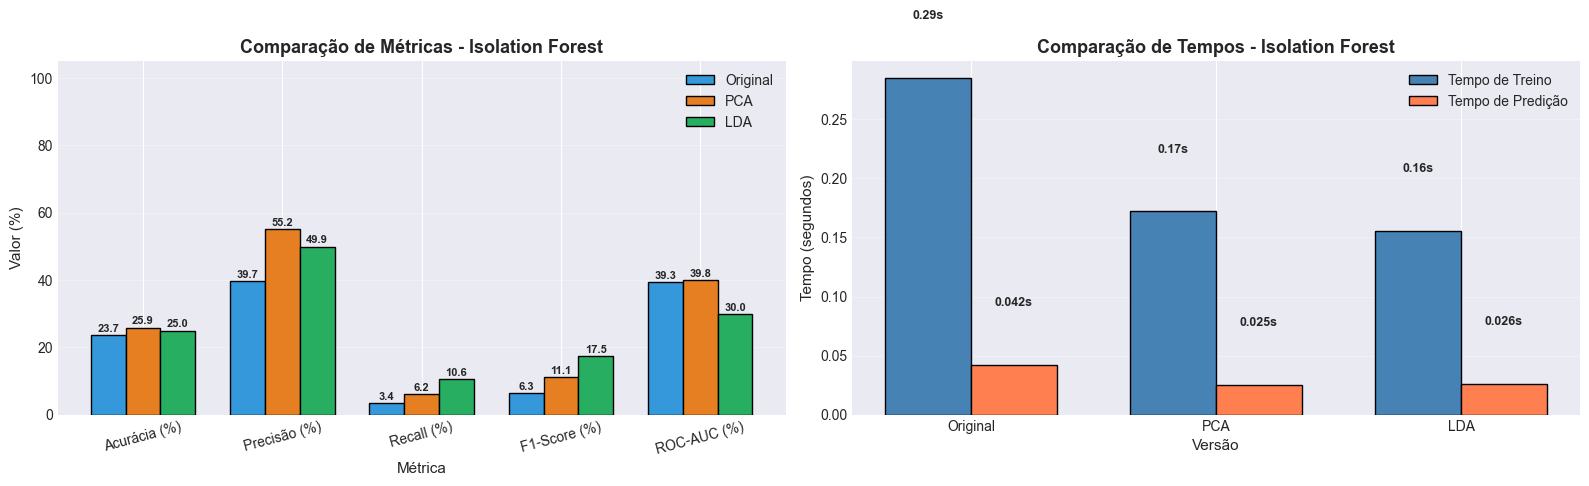

In [8]:
# visualização comparativa em gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# gráfico das métricas de classificação
metricas = ['Acurácia (%)', 'Precisão (%)', 'Recall (%)', 'F1-Score (%)', 'ROC-AUC (%)']
versoes = ['Original', 'PCA', 'LDA']
cores = ['#3498db', '#e67e22', '#27ae60']

x_pos = np.arange(len(metricas))
largura = 0.25

for i, versao in enumerate(versoes):
    valores = [df_comparacao.loc[df_comparacao['Versão'] == versao, m].values[0] for m in metricas]
    axes[0].bar(x_pos + i*largura, valores, largura, label=versao, color=cores[i], edgecolor='black')

axes[0].set_xlabel('Métrica', fontsize=11)
axes[0].set_ylabel('Valor (%)', fontsize=11)
axes[0].set_title('Comparação de Métricas - Isolation Forest', fontsize=13, fontweight='bold')
axes[0].set_xticks(x_pos + largura)
axes[0].set_xticklabels(metricas, rotation=15)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 105])

# adicionando valores nas barras
for i, versao in enumerate(versoes):
    valores = [df_comparacao.loc[df_comparacao['Versão'] == versao, m].values[0] for m in metricas]
    for j, v in enumerate(valores):
        axes[0].text(x_pos[j] + i*largura, v + 1, f'{v:.1f}',
                     ha='center', fontsize=8, fontweight='bold')

# gráfico dos tempos de execução
tempos_treino = df_comparacao['Tempo Treino (s)'].values
tempos_pred = df_comparacao['Tempo Pred. (s)'].values

x_pos2 = np.arange(len(versoes))
largura2 = 0.35

axes[1].bar(x_pos2 - largura2/2, tempos_treino, largura2,
            label='Tempo de Treino', color='steelblue', edgecolor='black')
axes[1].bar(x_pos2 + largura2/2, tempos_pred, largura2,
            label='Tempo de Predição', color='coral', edgecolor='black')

axes[1].set_xlabel('Versão', fontsize=11)
axes[1].set_ylabel('Tempo (segundos)', fontsize=11)
axes[1].set_title('Comparação de Tempos - Isolation Forest', fontsize=13, fontweight='bold')
axes[1].set_xticks(x_pos2)
axes[1].set_xticklabels(versoes)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# adicionando valores
for i, (t, p) in enumerate(zip(tempos_treino, tempos_pred)):
    axes[1].text(i - largura2/2, t + 0.05, f'{t:.2f}s', ha='center', fontweight='bold', fontsize=9)
    axes[1].text(i + largura2/2, p + 0.05, f'{p:.3f}s', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


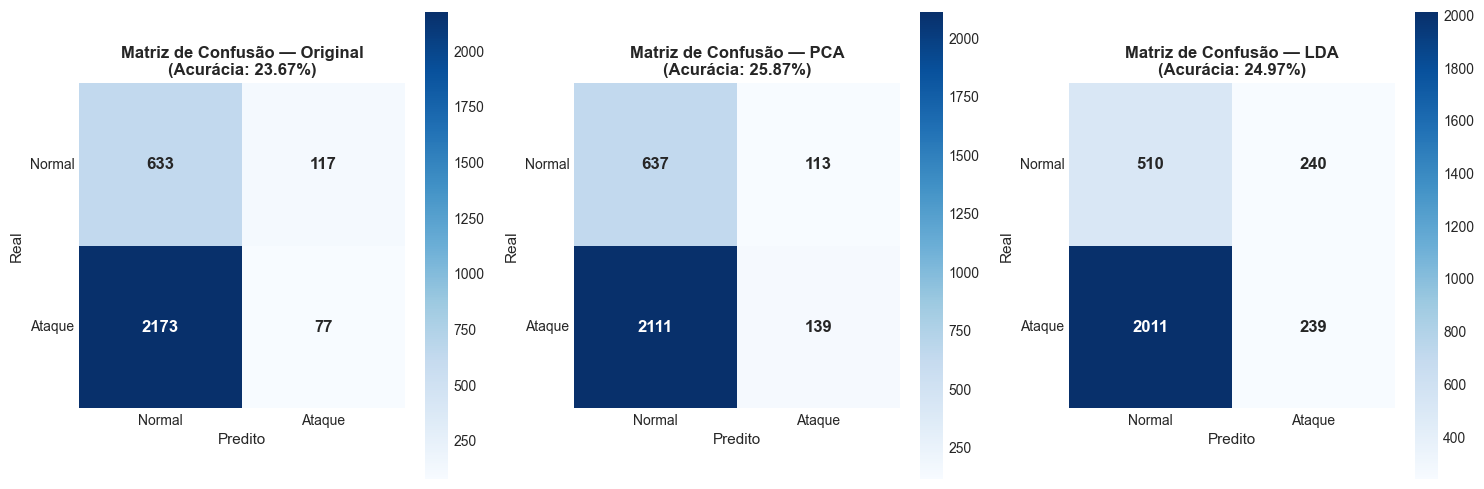

  Diagonal principal = acertos
  Fora da diagonal   = erros
  Linha = classe real | Coluna = classe de previsão


In [9]:
# mostrando as 3 matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

nomes_classes_bin = ['Normal', 'Ataque']

for idx, (versao, dados) in enumerate(resultados.items()):
    cm = confusion_matrix(y_test_bin, dados['y_pred'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=nomes_classes_bin, yticklabels=nomes_classes_bin,
                ax=axes[idx], cbar=True, square=True,
                annot_kws={'fontsize': 12, 'fontweight': 'bold'})

    axes[idx].set_xlabel('Predito', fontsize=11)
    axes[idx].set_ylabel('Real', fontsize=11)
    axes[idx].set_title(f'Matriz de Confusão — {versao}\n(Acurácia: {dados["acuracia"]*100:.2f}%)',
                        fontsize=12, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=0)
    axes[idx].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

print("  Diagonal principal = acertos")
print("  Fora da diagonal   = erros")
print("  Linha = classe real | Coluna = classe de previsão")


In [10]:
# mostrando o relatório de classificação completo para cada versão
nomes_classes_bin = ['Normal', 'Ataque']

for versao, dados in resultados.items():
    print(f"\n{'='*65}")
    print(f"Relatório de classificação — Isolation Forest ({versao})")
    print(f"{'='*65}")
    print(classification_report(
        y_test_bin, dados['y_pred'],
        target_names=nomes_classes_bin,
        digits=4
    ))



Relatório de classificação — Isolation Forest (Original)
              precision    recall  f1-score   support

      Normal     0.2256    0.8440    0.3560       750
      Ataque     0.3969    0.0342    0.0630      2250

    accuracy                         0.2367      3000
   macro avg     0.3112    0.4391    0.2095      3000
weighted avg     0.3541    0.2367    0.1363      3000


Relatório de classificação — Isolation Forest (PCA)
              precision    recall  f1-score   support

      Normal     0.2318    0.8493    0.3642       750
      Ataque     0.5516    0.0618    0.1111      2250

    accuracy                         0.2587      3000
   macro avg     0.3917    0.4556    0.2377      3000
weighted avg     0.4716    0.2587    0.1744      3000


Relatório de classificação — Isolation Forest (LDA)
              precision    recall  f1-score   support

      Normal     0.2023    0.6800    0.3118       750
      Ataque     0.4990    0.1062    0.1752      2250

    accuracy      

In [11]:
# salvando os 3 modelos treinados e as métricas
print("Salvando modelos e métricas\n")

# caminhos para salvar os modelos
caminhos_modelos = {
    'Original': os.path.join(pasta_modelos, 'modelo_if_original.pkl'),
    'PCA': os.path.join(pasta_modelos, 'modelo_if_pca.pkl'),
    'LDA': os.path.join(pasta_modelos, 'modelo_if_lda.pkl')
}

# salvando cada modelo
for versao, caminho in caminhos_modelos.items():
    joblib.dump(resultados[versao]['modelo'], caminho)
    tamanho_mb = os.path.getsize(caminho) / (1024 * 1024)
    print(f"  Modelo isolation forest {versao}: {caminho} ({tamanho_mb:.2f} MB)")

# salvando métricas num arquivo csv para análise em proximas etapas
pasta_resultados = '../resultados/metricas/'
os.makedirs(pasta_resultados, exist_ok=True)

caminho_metricas = os.path.join(pasta_resultados, 'metricas_isolation_forest.csv')
df_comparacao.to_csv(caminho_metricas, index=False)
print(f"\n Métricas salvas: {caminho_metricas}")


Salvando modelos e métricas

  Modelo isolation forest Original: ../modelos/modelo_if_original.pkl (0.82 MB)
  Modelo isolation forest PCA: ../modelos/modelo_if_pca.pkl (0.80 MB)
  Modelo isolation forest LDA: ../modelos/modelo_if_lda.pkl (1.17 MB)

 Métricas salvas: ../resultados/metricas/metricas_isolation_forest.csv


In [12]:
# resumo
print("\n" + "="*65)
print("RESUMO FINAL — Isolation Forest")
print("="*65)

print(f"\nModelos treinados: 3 (Original, PCA, LDA)")
print(f"\nRanking por F1-Score:")
ranking = df_comparacao.sort_values('F1-Score (%)', ascending=False)
for i, (_, row) in enumerate(ranking.iterrows(), 1):
    print(f"   {i}º — {row['Versão']:<10} F1: {row['F1-Score (%)']:.2f}%  |  Acc: {row['Acurácia (%)']:.2f}%  |  ROC-AUC: {row['ROC-AUC (%)']:.2f}%")

print(f"\nEficiência:")
mais_rapido_treino = df_comparacao.loc[df_comparacao['Tempo Treino (s)'].idxmin(), 'Versão']
mais_rapido_pred = df_comparacao.loc[df_comparacao['Tempo Pred. (s)'].idxmin(), 'Versão']
print(f"  Treinamento mais rápido:  {mais_rapido_treino}")
print(f"  Predição mais rápida:     {mais_rapido_pred}")



RESUMO FINAL — Isolation Forest

Modelos treinados: 3 (Original, PCA, LDA)

Ranking por F1-Score:
   1º — LDA        F1: 17.52%  |  Acc: 24.97%  |  ROC-AUC: 29.96%
   2º — PCA        F1: 11.11%  |  Acc: 25.87%  |  ROC-AUC: 39.83%
   3º — Original   F1: 6.30%  |  Acc: 23.67%  |  ROC-AUC: 39.30%

Eficiência:
  Treinamento mais rápido:  LDA
  Predição mais rápida:     PCA
